# Inference basics

## Bayesian Inference with SVGD (Stein Variational Gradient Descent)

To estimate model parameters and their confidence intervals, Phasic used uses Stein Variational Gradient Descent (SVGD), which represents the posterior with a set of particles (parameter vectors) and combines ideas from optimization, kernel methods, and functional analysis in a deterministic algorithm that updates these particles iteratively to move them toward the posterior distribution. SVGD exploits the PDF for gradient computation and moments for regularization. It begins with an initial set of particles (typically drawn from the prior or from a simple distribution) and iteratively transport these particles toward the posterior using gradient information. Each particle interacts with all other particles through a kernel function, with the interaction strength depending on the distance between particles. This interaction ensures that particles spread out to cover the posterior distribution, allowing extraction of not only the most likely parameter value (MAP estimate) but also a confidence interval of the estimate.

Such inference is not possible in the standard matrix formulation of phase-type distributions where the large number of likelihood computations required would each be $O(n^3)$. In Phasic, the algorithm of the gaussian elimination on the graph fully exploits the sparseness of state spaces bringing the complexity closer to $n^2$. Because Phasic records and caches the elimination trace, this computation is only done once, removing a dimension of complexity for all subsequent likelihood evaluations. For an expose of these tricks and innovations see [Math and Algorithms](../../mathref/index.qmd), [Architecture](../internals/architecture.qmd), [Caching](./trace-and-jax-caching.ipynb) and [Sharing](./sharing.ipynb).





:::

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization, clear_caches, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

set_log_level('INFO')

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

clear_caches()

[INFO] phasic.graph_cache: Cleared 0 cached graphs


  Removed 14 file(s), preserved directory structure
  Removed 1 file(s), preserved directory structure


Lets make a coalescent moddel with one parameter, the coalescent rate:

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

Construct the graph and set some value of the model parameter:

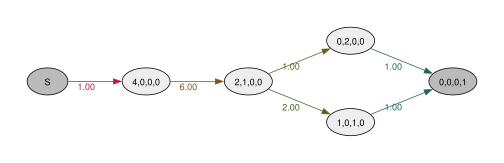

In [3]:
graph = Graph(coalescent_1param)
graph.plot()

With a large set of observed times to the most recent common ancestor (TMRCA), we can fit our model to find the most likely value of the model parameter. For this turorial we will just set the model parameter to 7 and then sample from the model to get such a data set. This has the advantage that we know what the model parameter is supposed to be.

In [4]:
true_theta = [7]
graph.update_weights(true_theta)
nr_observations = 10000
observed_data = graph.sample(nr_observations)

We can plot a histogram of the observed data along with the theoretical density to see that they match up:

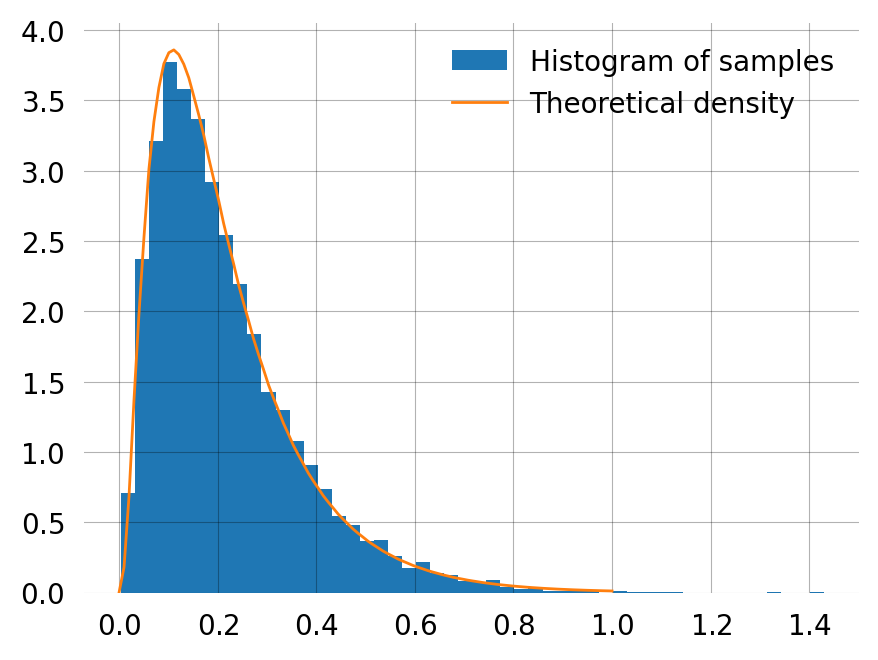

In [5]:
fig, ax = plt.subplots()
ax.hist(observed_data, density=True, bins=50, label='Histogram of samples')
x = np.linspace(0, 1, 100)
ax.plot(x, graph.pdf(x), color='C1', lw=1, label='Theoretical density')
ax.legend() ;

The `svgd` method provide sensible defaults to the optimization parameters. So in the simplest version, all you have to do to fit parameter values is:

In [6]:
svgd = graph.svgd(observed_data, n_iterations=200)

In [7]:
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9275     6.8709     0.1566     6.7024       7.2259      

Particles: 24, Iterations: 200


In [8]:
svgd.learning_rate

0.0001

However, you should always evaluate convergence of the SVGD optimization. The `plot_trace`, shows the parameter values of each particle across iterations:

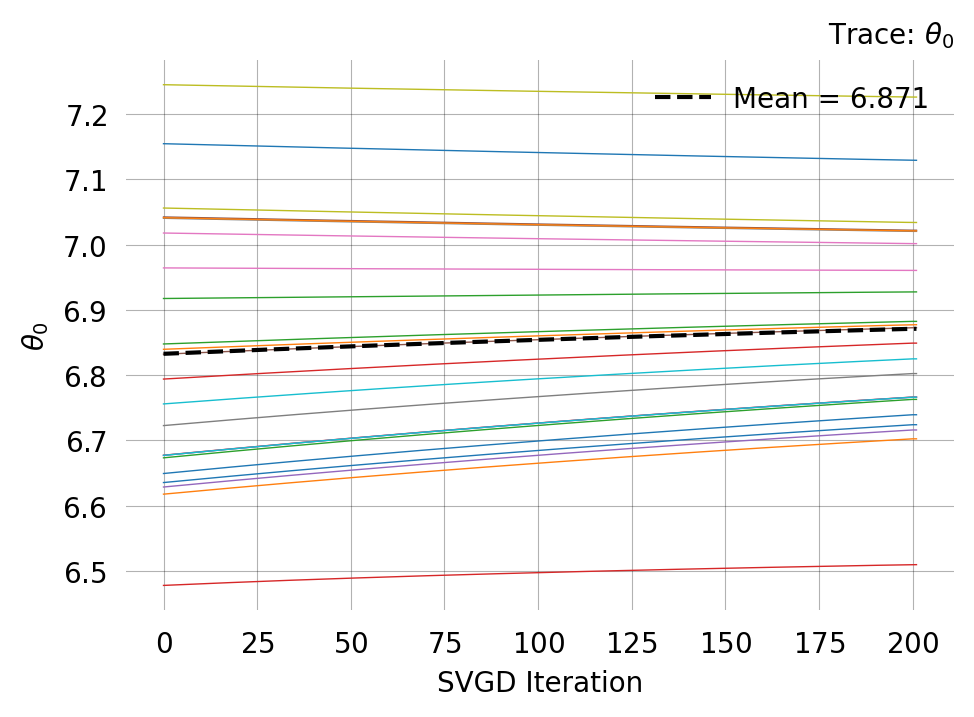

In [9]:
svgd.plot_trace();

The distribution of particle values describe the posterior distribution from which a mean and CI can be computed:

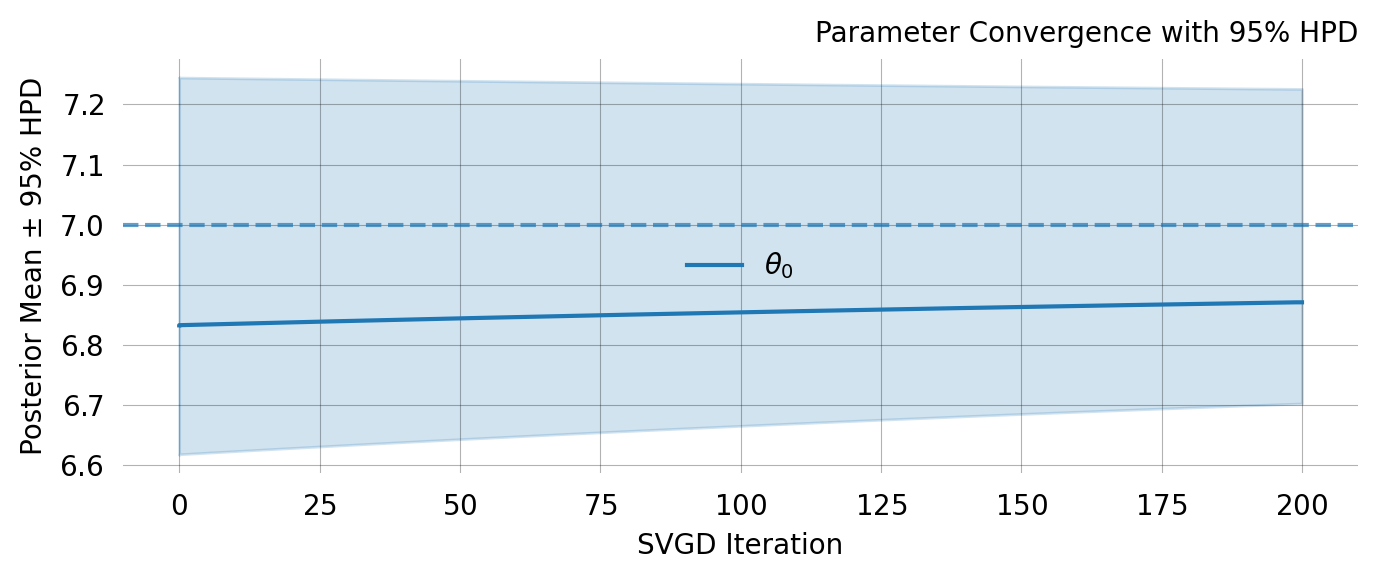

In [10]:
svgd.plot_ci(true_theta=true_theta) ;

A nice property of SVGD is that you can easily evaluate if the optimization converges. In this case it clearly does not. Fortunately there are several easy remedies for this as shown below.

## Prior

The prior distribution used in Bayesian inference represents our prior belief, I.e. our knowledge about what range of values the parameter can reasonably take. Phasic comes with two types of priors that are easily defined from basic knowledge about the parameter. The default behaviour of Phasic is to use a Gaussian prior centered on a rough estimate of each parameter using method-of-moments. To see the prior used, you can can plot it like this:

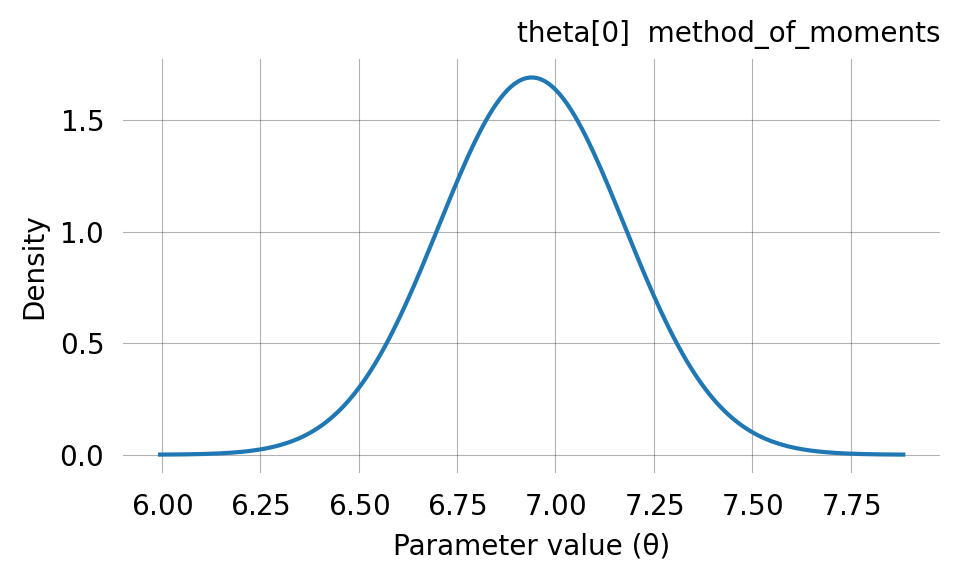

In [11]:
svgd.prior.plot() ;

or reconstruct the GaussPrior from its properties:

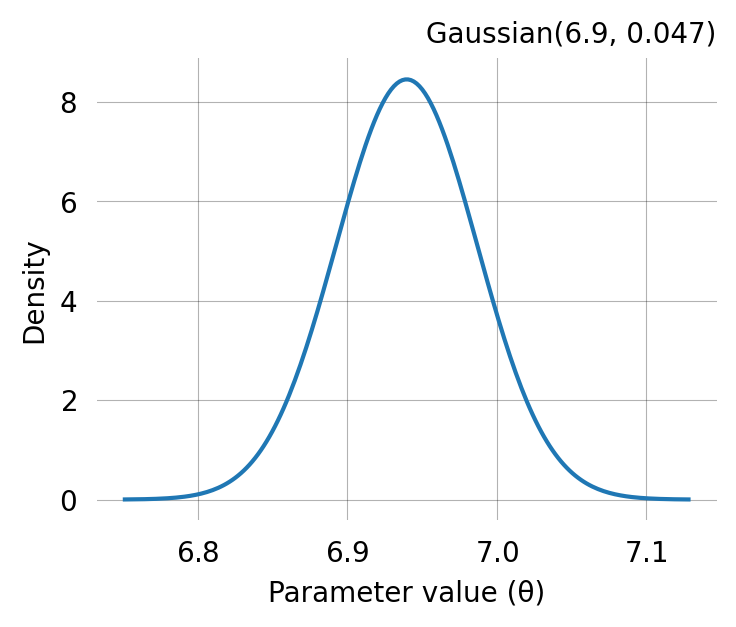

In [12]:
GaussPrior(mean=svgd.prior.theta.item(), std=svgd.prior.std.item()).plot() ;




You can define your own Gaussian prior (`GaussPrior`) or a Half-Cauchy prior (`HalfCauchy`). 

The Half-Cauchy can be defined by the scale parameter or the upper bound of of the CI.

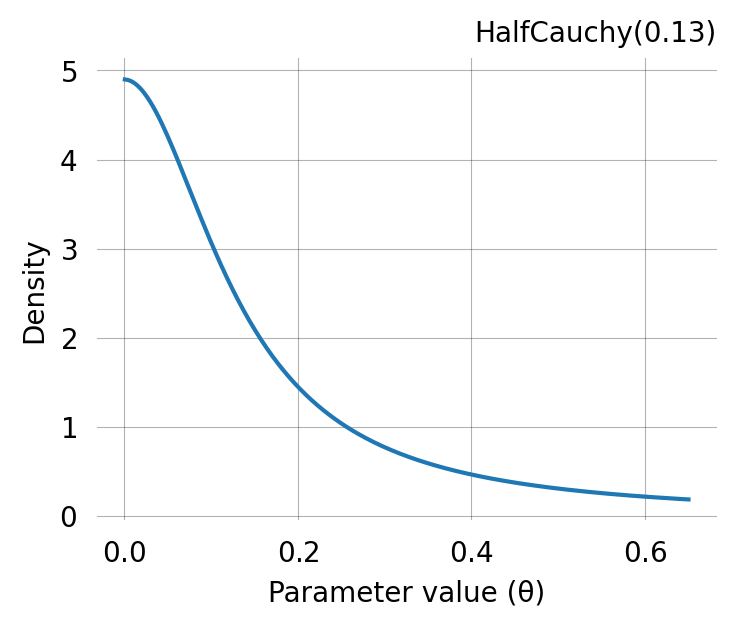

In [13]:
prior = HalfCauchyPrior(ci=0.4, prob=0.8)
prior.plot();

The Gaussian can be defined by either mean and SD or a confidence interval:

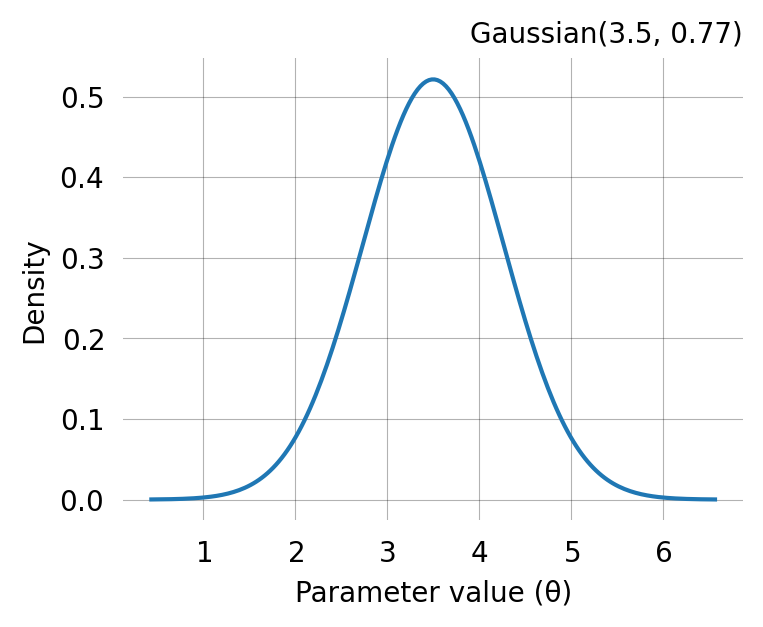

In [14]:
# prior = Prior(mean=5, std=2) 
prior = GaussPrior(ci=[2, 5])
prior.plot();

::: { .callout-tip }

The `GaussPrior` and `HalfCauchyPrior` classes provide the log-probabilities needed for SVGD. If you want to provide your own prior function, it must return such log-probabilities.

:::

Lets add the prior to SVGD inference and rerun it.

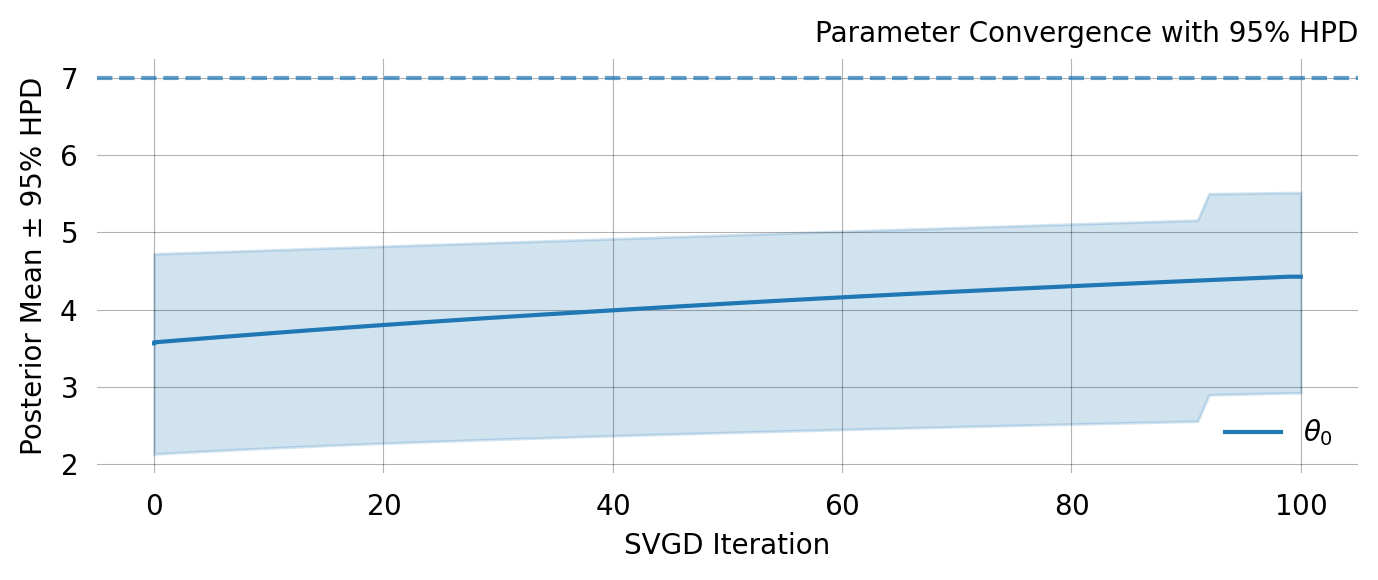

In [15]:
svgd = graph.svgd(observed_data, 
                  prior=prior
                  )
svgd.plot_ci(true_theta=true_theta) ;

In [16]:
svgd.analyze_trace()

NOT CONVERGED after 102 iterations

Detected Issues:
  ⚠ Did not converge within n_iterations
Learning Rate: Not converged - use decay schedule for better convergence
  ExpStepSize(
      first_step=0.00015000000000000001,
      last_step=1e-05,
      tau=51.0
  )
Particles: High ESS ratio (1.00) - could reduce particles
  n_particles=20
Iterations: Did not converge
  Increase to n_iterations=153
Optimizer: Consider using an adaptive optimizer
  Options (from phasic import Adam, SGDMomentum, RMSprop, Adagrad):
    Adam(lr=0.01)     - Adaptive LR + momentum (recommended)
    SGDMomentum(lr=0.01)      - Momentum only
    RMSprop(lr=0.001)         - Adaptive LR, no momentum
    Adagrad(lr=0.01)          - Cumulative gradient scaling


That is better, but it still does not converge to the true theta value. We can change the learning rate from its default value of 0.01:

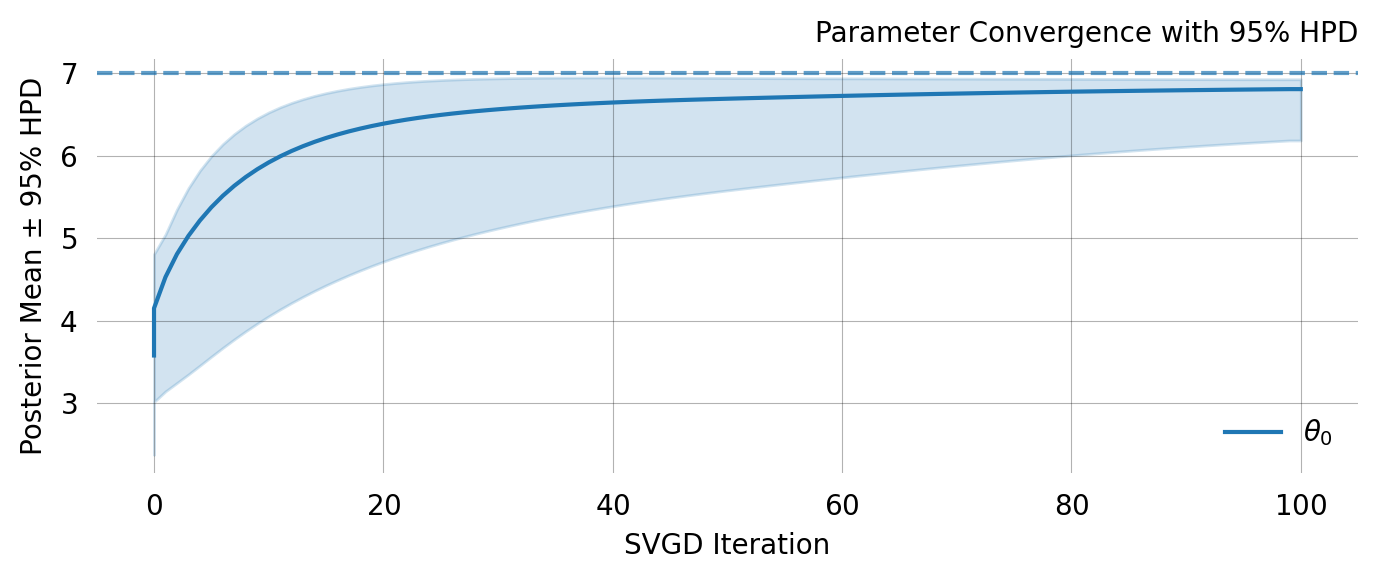

In [17]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=0.05
                  )
svgd.plot_ci(true_theta=true_theta)

Or even better, we can make the learning rate start our large and decay exponentially during training:

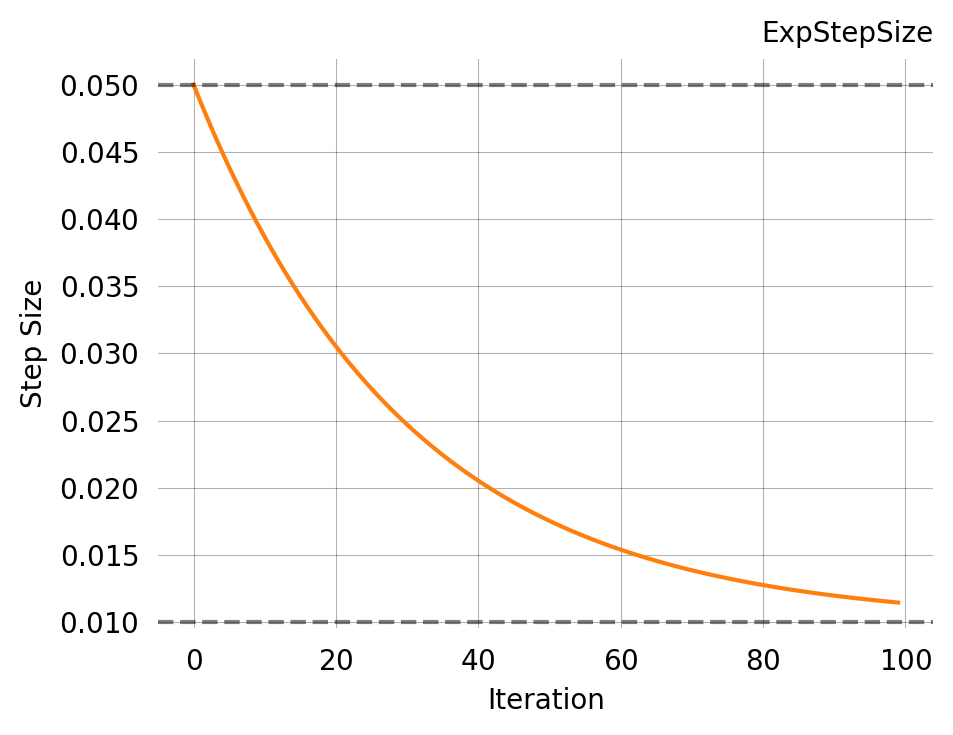

In [18]:
step_schedule = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)
step_schedule.plot(100);

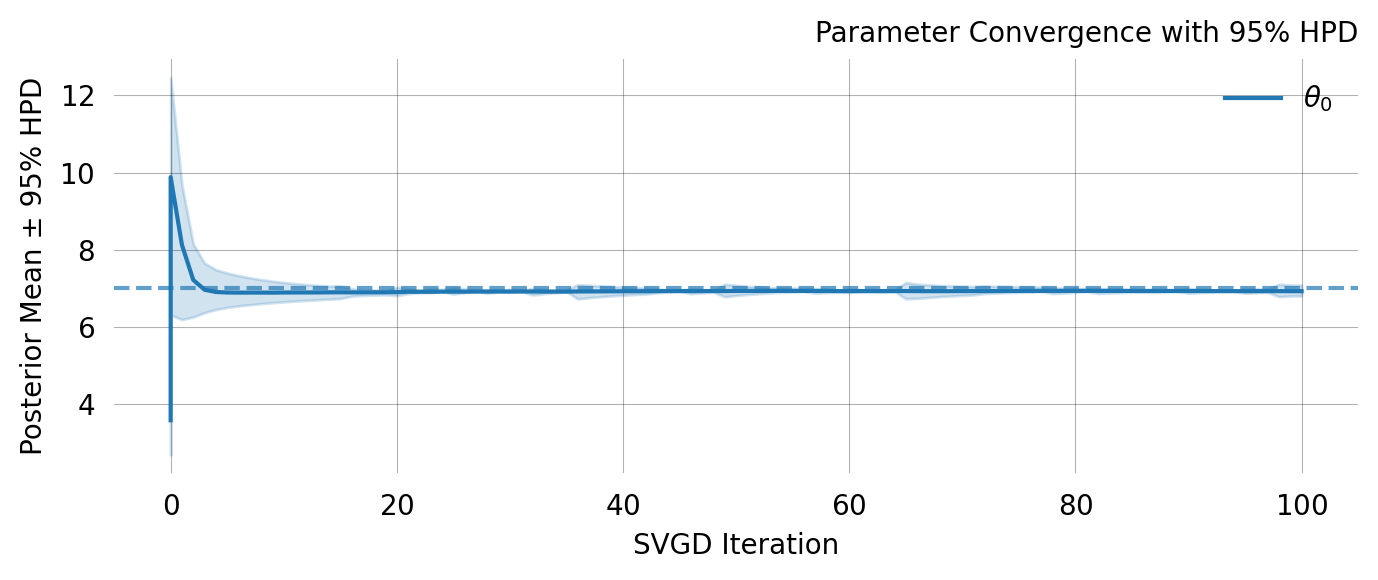

In [19]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=step_schedule
                  )
svgd.plot_ci(true_theta=true_theta)

To see how the posteorior evolves over iterations, we can plot both mean and Std:

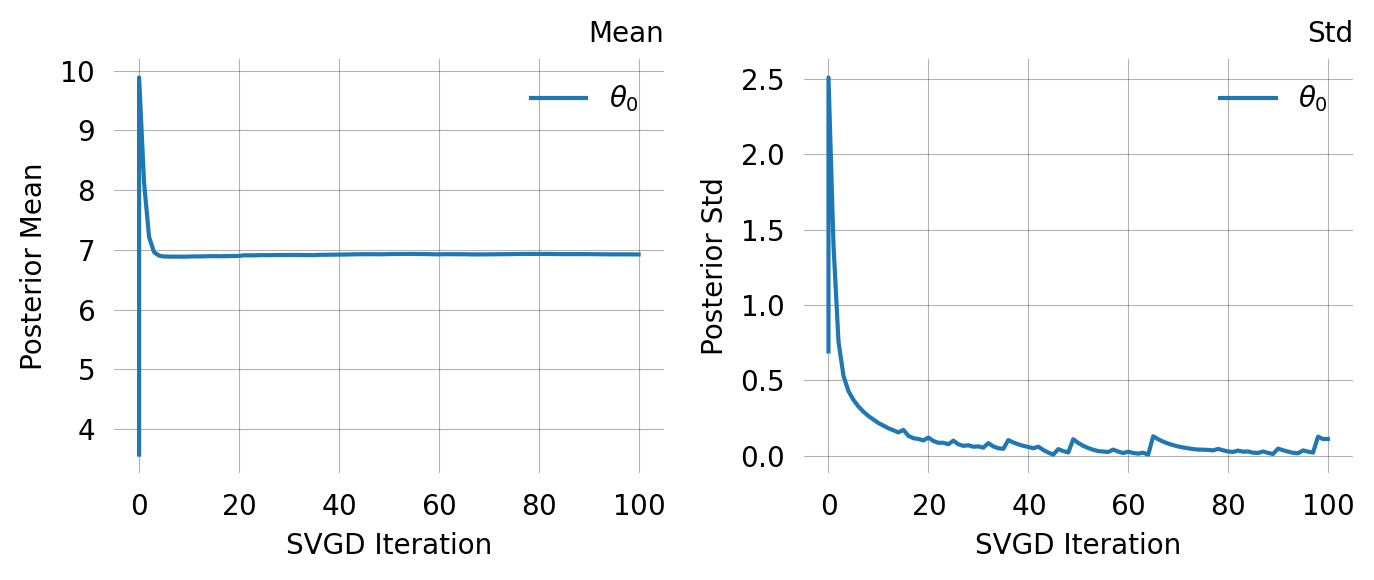

In [20]:
svgd.plot_convergence() ;

In [21]:
#svgd.animate(duration=5)

We can also help optimization by applying moment regularization across iterations:

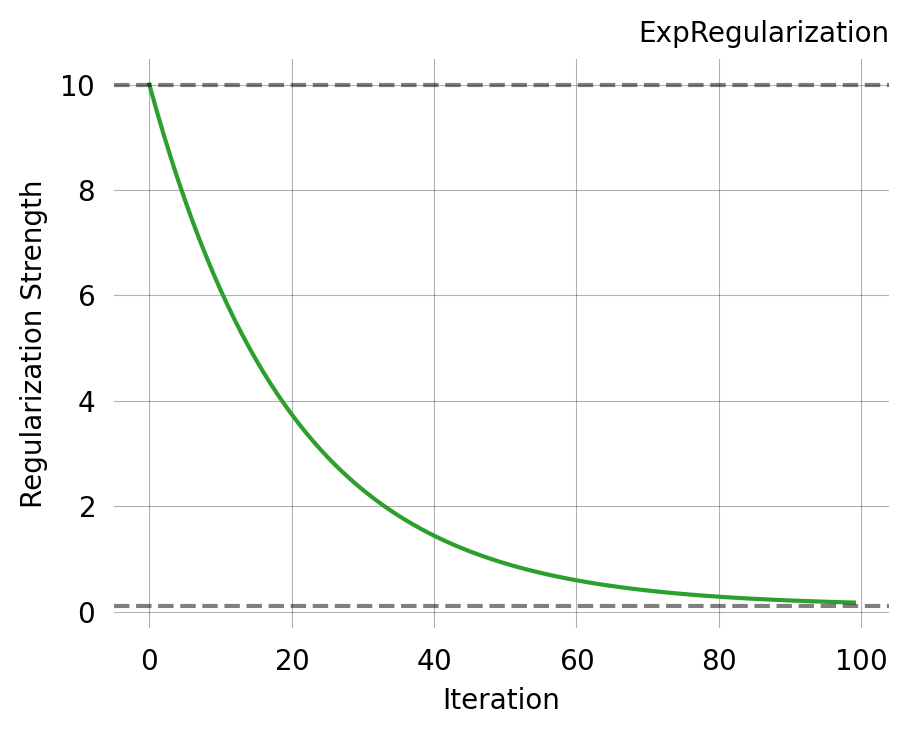

In [22]:
reg_schedule = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0)
reg_schedule.plot(100) ;

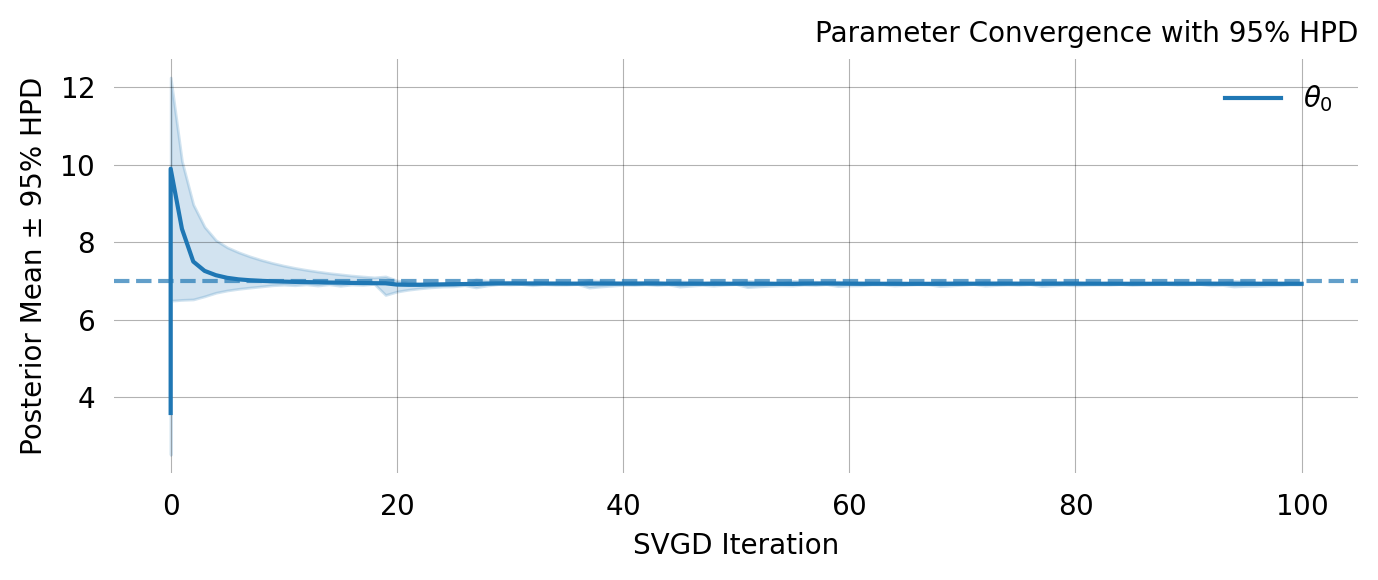

In [23]:
svgd = graph.svgd(observed_data, 
                  prior=prior, 
                  learning_rate=step_schedule,
                  regularization=reg_schedule,
                  nr_moments=2
                  )
svgd.plot_ci(true_theta=true_theta)

It does not contribute much in this case that already converges, but for more complex models using regularization can help stabilize the optimization.

Posterior predictive checks

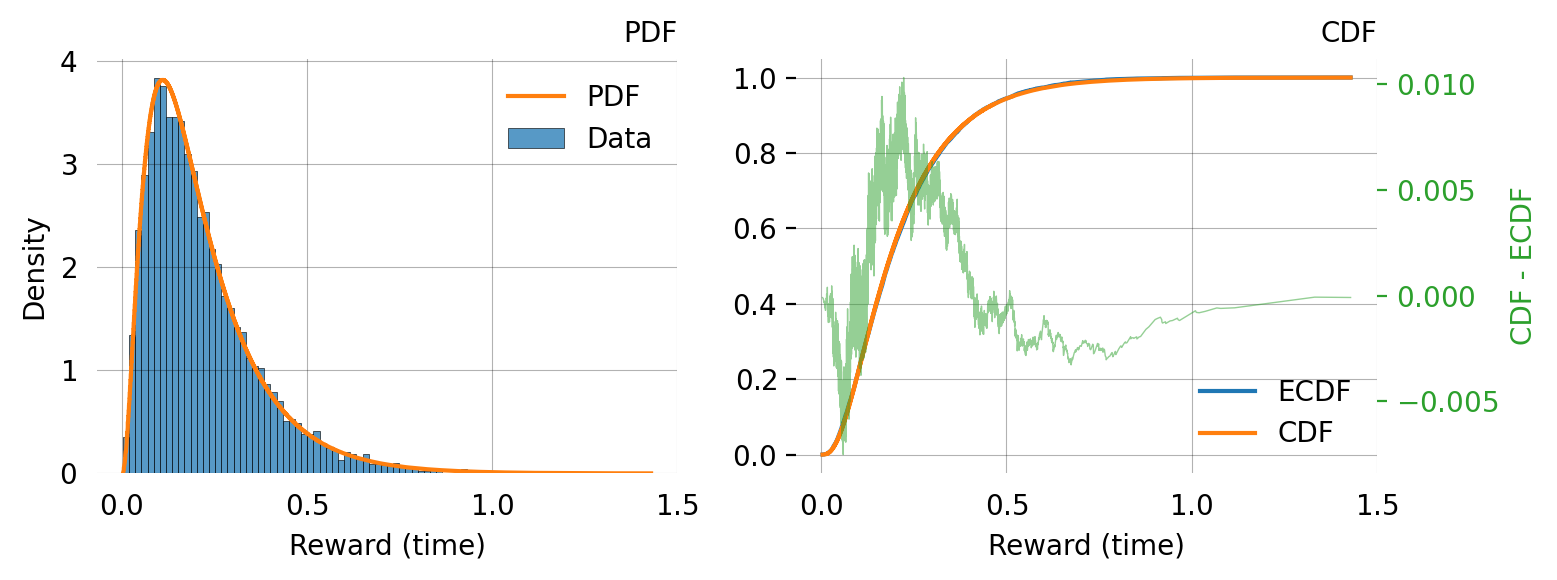

In [24]:
from scipy.stats import ecdf

# ECDF for observed data
res = ecdf(observed_data)
x, ecdf = res.cdf.quantiles, res.cdf.probabilities

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
sns.histplot(observed_data,
             kde=False, stat='density', label='Data', ax=ax1)
graph.update_weights(svgd.get_results()['theta_mean'])
ax1.plot(x, graph.pdf(x), lw=1.5, c='C1', label='PDF')
ax1.set_xlabel('Reward (time)')
ax1.set_title('PDF')
ax1.legend()
ax2.plot(x, ecdf, lw=1.5, c='C0', label='ECDF')
ax2.plot(x, graph.cdf(x), lw=1.5, c='C1', label='CDF')
ax2.set_xlabel('Reward (time)')
ax2.set_title('CDF')
ax2.legend() 
ax3 = ax2.twinx()
ax3.plot(x, graph.cdf(x)-ecdf, lw=0.5, c='C2', 
    alpha=0.5,label='CDF-ECDF')
ax3.grid(False)
ax3.set_ylabel('CDF - ECDF', color='C2')
ax3.tick_params(axis='y', colors='C2')
plt.tight_layout()

## Adaptive optimizers

Phasic provides three optimizers for SVGD that offer adaptive per-parameter learning rates. These can be particularly useful when gradients have vastly different scales across parameters or when fixed step sizes cause oscillation.

#### Adam

When using `Adam`, the `learning_rate` parameter passed to SVGD is ignored in favor of the optimizer's learning rate.

`Adam` (Adaptive Moment Estimation) maintains running estimates of two quantities for each parameter:

1. **First moment ($m$)**: An exponentially weighted average of past gradients (momentum)
2. **Second moment ($v$)**: An exponentially weighted average of past squared gradients (gradient variance)

**Update rule:**

$$
\begin{align}
m &\leftarrow \beta_1 \cdot m + (1 - \beta_1) \cdot g \\
v &\leftarrow \beta_2 \cdot v + (1 - \beta_2) \cdot g^2 \\[0.5em]
\hat{m} &= \frac{m}{1 - \beta_1^t} \\[0.5em]
\hat{v} &= \frac{v}{1 - \beta_2^t} \\[0.5em]
\theta &\leftarrow \theta - \alpha \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
\end{align}
$$

Each parameter gets its own effective learning rate:

- Parameters with consistently large gradients $\rightarrow$ larger $\hat{v}$ $\rightarrow$ smaller effective step
- Parameters with consistently small gradients $\rightarrow$ smaller $\hat{v}$ $\rightarrow$ larger effective step

This automatic scaling helps when different parameters naturally have different gradient magnitudes.

When fixed learning rate works well:

- Well-behaved optimization landscapes
- Parameters with similar gradient scales
- When you've tuned the learning rate carefully

When Adam helps:

- Large datasets causing large gradient magnitudes
- Parameters with vastly different scales
- "Shark teeth" oscillation patterns in convergence
- When you want reasonable results without extensive tuning

Tuning Guidelines:

- learning_rate: Start with 0.001-0.01. If convergence is too slow, increase. If unstable, decrease.
- beta1: 0.9 works well for most cases. Lower values (0.8) give less momentum.
- beta2: 0.999 is standard. Lower values (0.99) adapt faster to gradient changes.
- epsilon: Rarely needs adjustment. Increase to 1e-7 if you see numerical issues.

Consider Adam when you observe:

- Oscillating convergence ("shark teeth" pattern in loss)
- Different parameters converging at different rates
- Sensitivity to learning rate choice
- Large datasets** causing large gradient magnitudes

Stick with fixed learning rate when:

- Convergence is already smooth and fast
- You've tuned the learning rate well for your problem
- You want minimal computational overhead
- The optimization landscape is well-behaved

[Kingma and Ba (2014)](https://arxiv.org/abs/1412.6980) - Adam: A Method for Stochastic Optimization. arXiv:1412.6980.



In [25]:
from phasic import Adam

optimizer = Adam(
    learning_rate=0.001,  # Base learning rate, scaled per-parameter by Adam (alpha)
    beta1=0.9,            # Decay rate for first moment (momentum). Higher = more smoothing
    beta2=0.999,          # Decay rate for second moment. Higher = longer memory of gradient magnitudes
    epsilon=1e-8          # Small constant to prevent division by zero
)

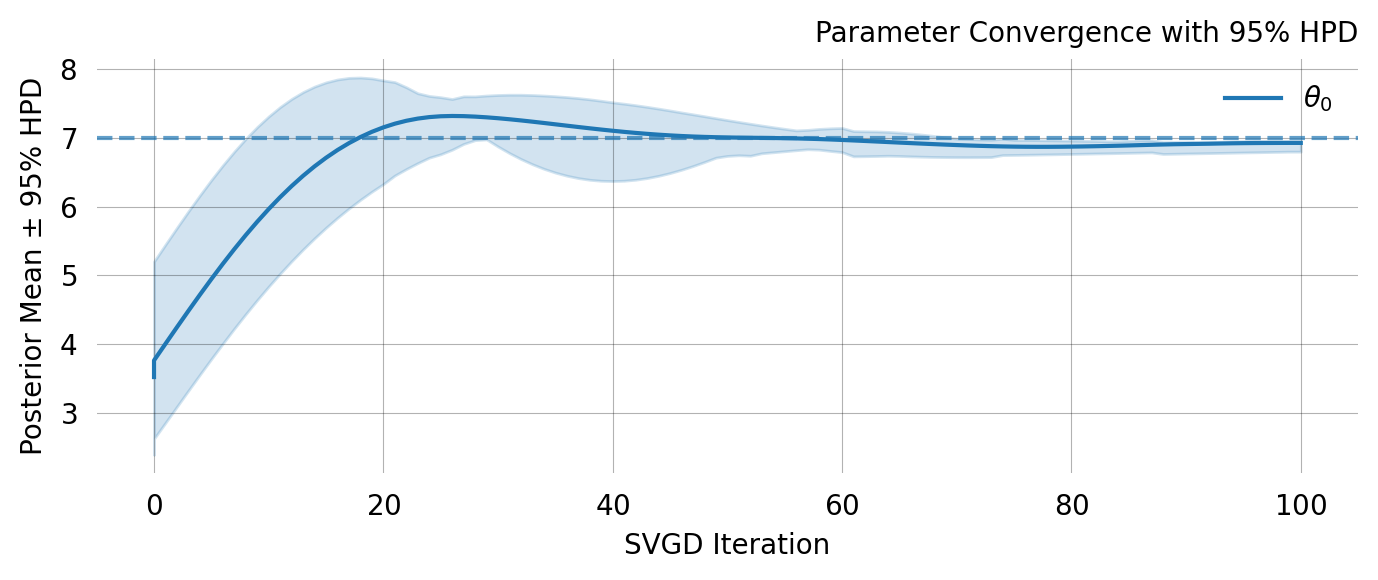

In [26]:
from phasic import Adam

svgd = graph.svgd(
    observed_data,
    prior = prior,
    optimizer=Adam(learning_rate=0.25),
)
svgd.plot_ci(true_theta=true_theta)

It can overcome even a misleading prior:

In [27]:
svgd = graph.svgd(
    observed_data,
    prior = GaussPrior(ci=[1, 3]),
    optimizer=Adam(learning_rate=0.25),
)
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.8940     6.8707     0.0316     6.8523       6.8940      

Particles: 24, Iterations: 100


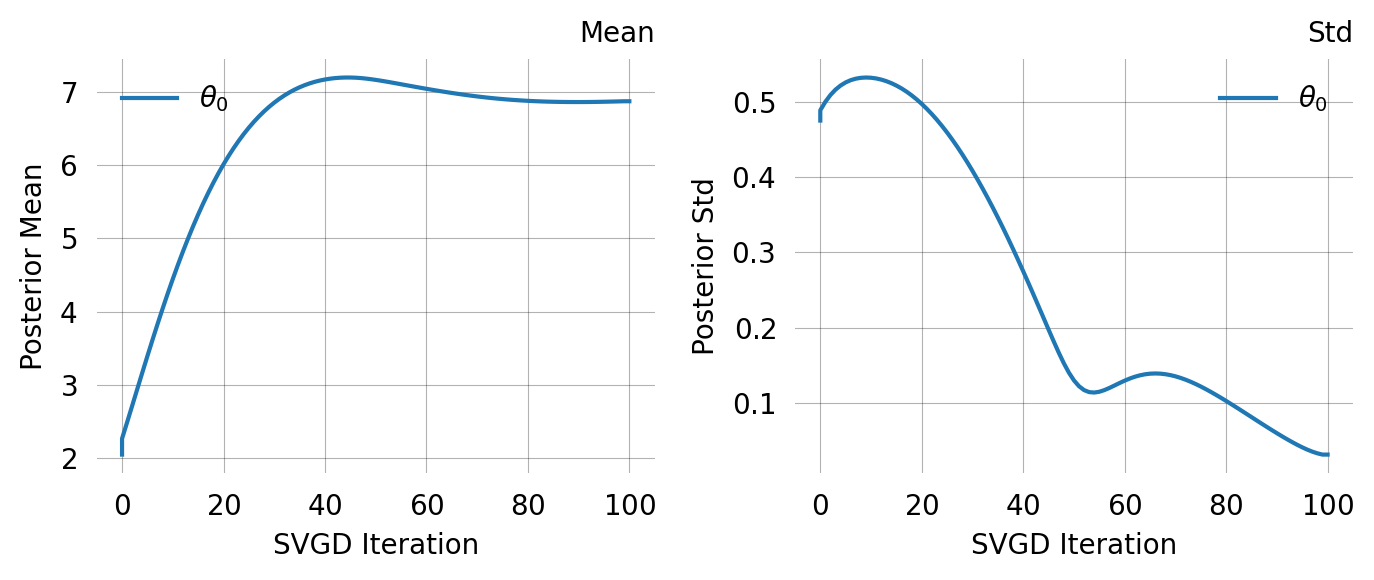

In [28]:
svgd.plot_convergence() ;

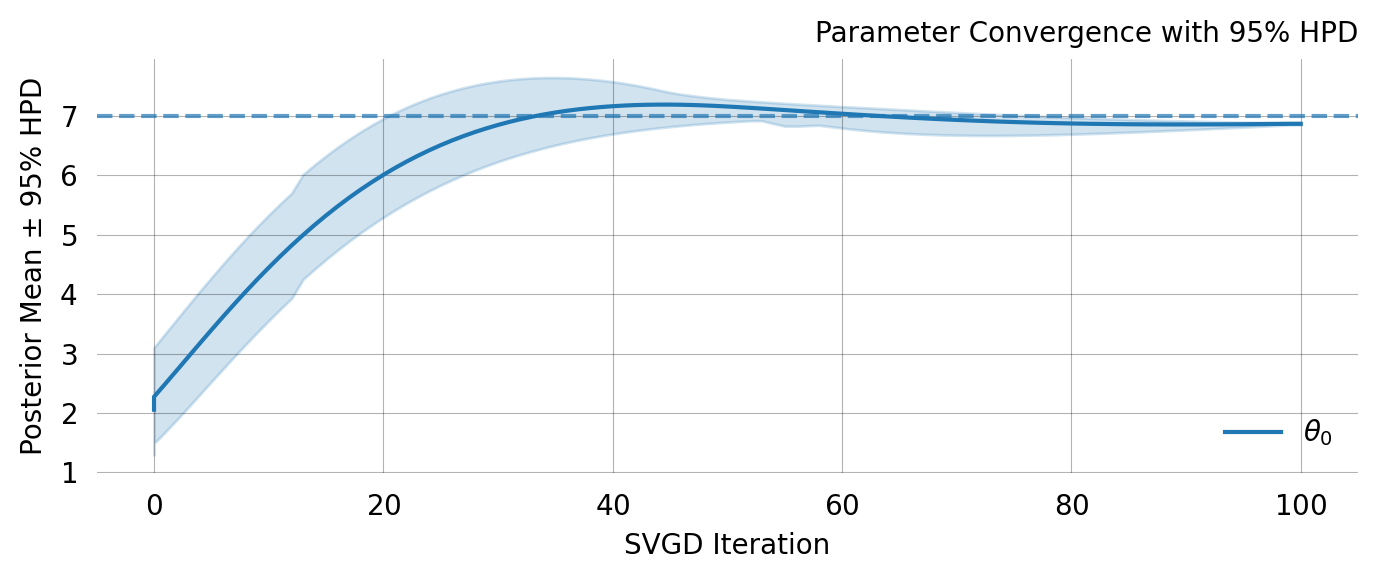

In [29]:
svgd.plot_ci(true_theta=true_theta) ;

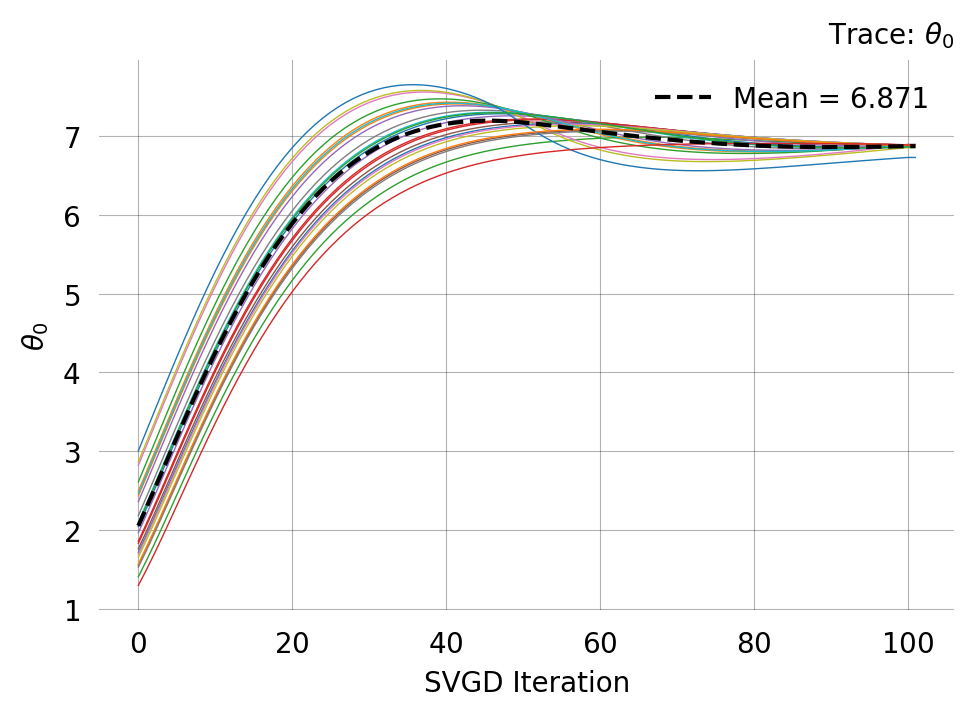

In [30]:
svgd.plot_trace() ;

#### SGDMomentum

`SGDMomentum` (SGD with momentum) accumulates velocity in directions of persistent gradient descent, helping accelerate convergence and dampen oscillations. Update rule:

$$
\begin{align}
v &= m * v + g \\
\theta &= \theta + (l * v)
\end{align}
$$

where $g$ is gradient $l$ is learning rate, and $m$ and $v$ are the first and second moments.

In [31]:
from phasic.svgd import SGDMomentum

optimizer = SGDMomentum(
    learning_rate=0.01,  # Step size
    momentum=0.9         # Momentum coefficient (0.9 standard, 0.99 high)
)
svgd = graph.svgd(
    observed_data,
    optimizer=optimizer,
)
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9381     6.9623     0.0929     6.8492       7.1538      

Particles: 24, Iterations: 100


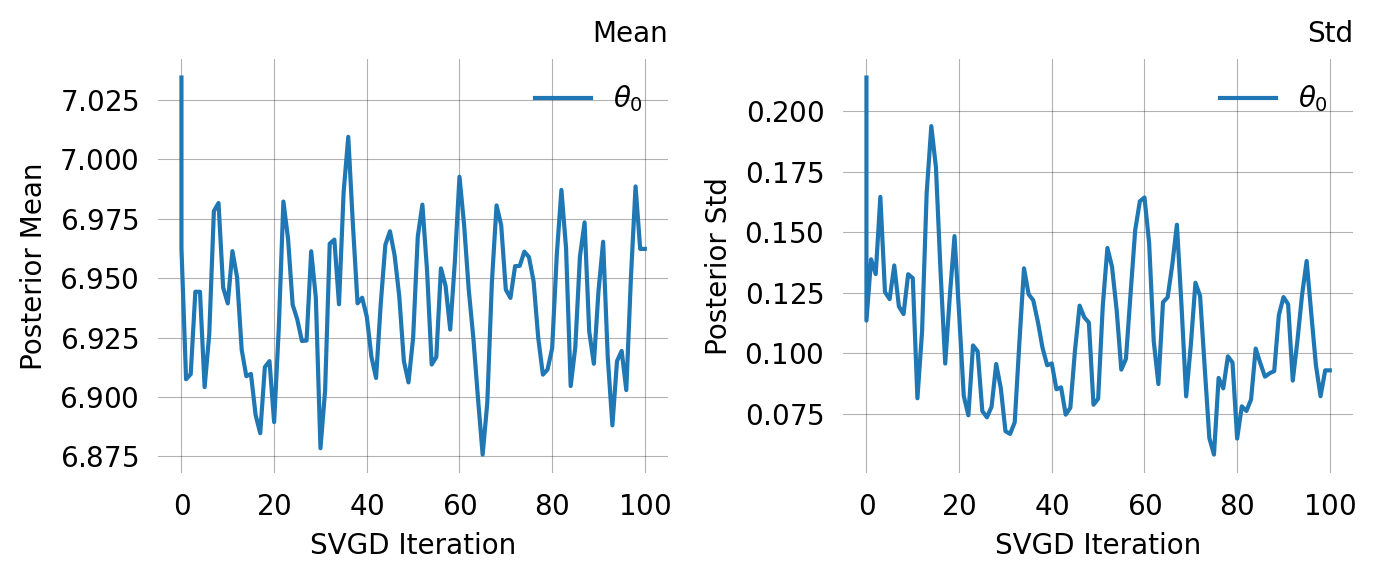

In [32]:
svgd.plot_convergence() ;

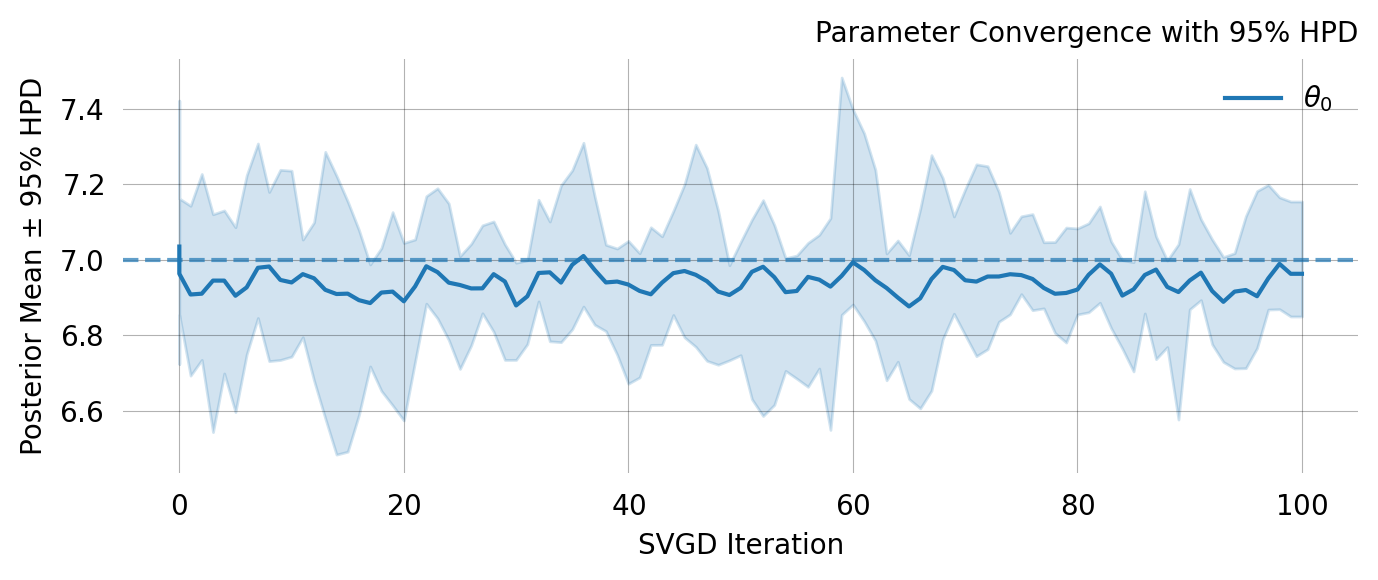

In [33]:
svgd.plot_ci(true_theta=true_theta) ;

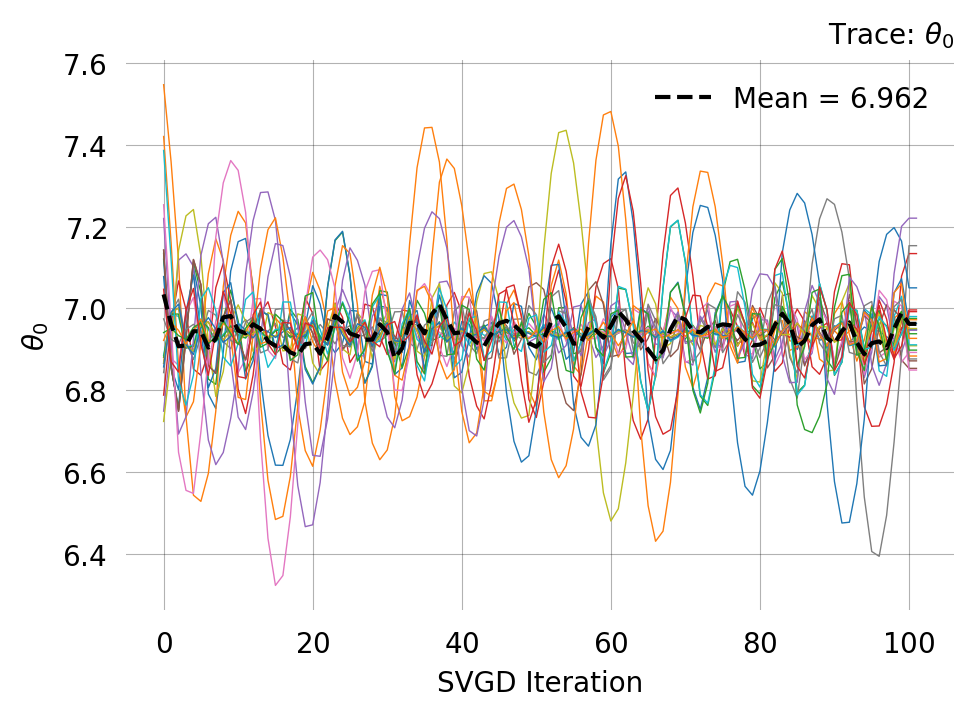

In [34]:
svgd.plot_trace() ;


#### RMSprop

`RMSprop` [(Hinton 2012)](https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf) divides the learning rate by an exponentially decaying average of squared gradients, adapting per-parameter. Update rule:

$$
\begin{align}

v &= d * v + (1 - d) * g^2 \\
\theta &= \theta + \frac{l * g}{\sqrt{v} + \epsilon}
\end{align}
$$

where $g$ is gradient $l$ is learning rate, $d$ is the decay and $v$ is 

In [35]:
from phasic.svgd import RMSprop

optimizer = RMSprop(
    learning_rate=1,  # Base learning rate (default 0.001)
    decay=0.99,       # Decay rate for squared gradient average
    epsilon=1e-8      # Numerical stability
)
svgd = graph.svgd(
    observed_data,
    optimizer=optimizer,
)
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9230     6.6979     0.2873     6.0273       6.9230      

Particles: 24, Iterations: 100


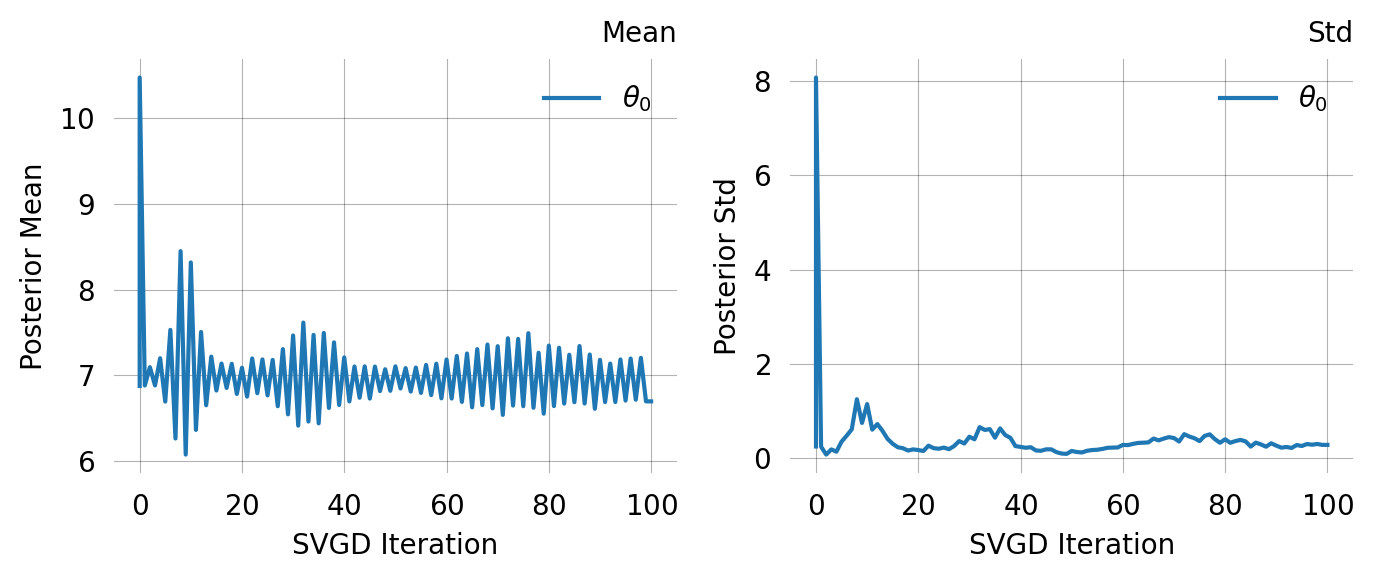

In [36]:
svgd.plot_convergence() ;

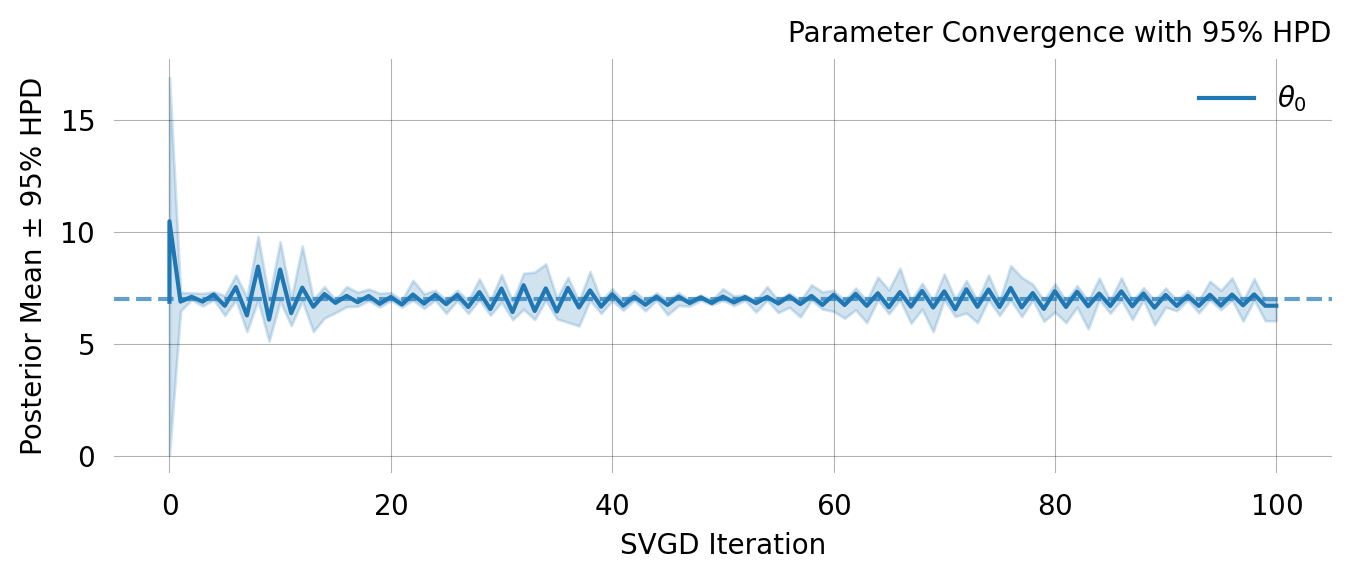

In [37]:
svgd.plot_ci(true_theta=true_theta) ;

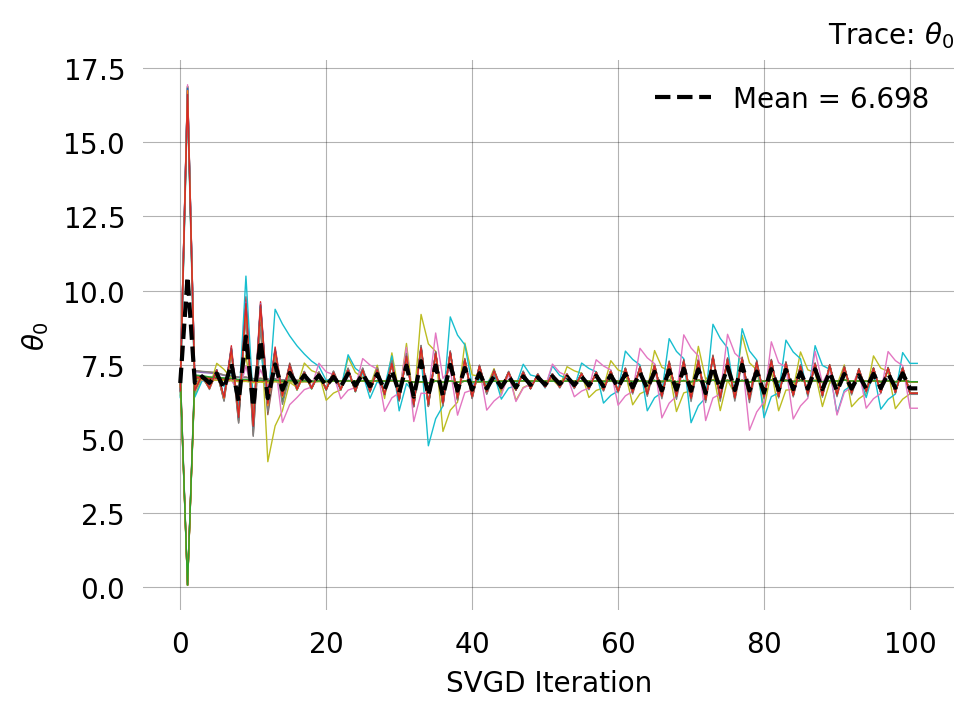

In [38]:
svgd.plot_trace() ;

#### Adagrad

`Adagrad` [(Duchi et al. 2011)](https://jmlr.org/papers/v12/duchi11a.html) accumulates the sum of squared gradients, giving smaller learning rates to parameters with large accumulated gradients. Update rule:

$$
\begin{align}
G &= g^2 \\
\theta &= \theta \frac{l * g}{\sqrt{G} + \epsilon}
\end{align}
$$

The learning rate of `Adagrad` decays over time as $G$ accumulates. For long runs, `RMSprop` or `Adam` may perform better.

In [39]:
from phasic import Adagrad

optimizer = Adagrad(
    learning_rate=2,  # Base learning rate (default 0.001)
    epsilon=1e-8         # Numerical stability
)
svgd = graph.svgd(
    observed_data,
    optimizer=optimizer,
)
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         6.9395     6.9329     0.0277     6.8782       6.9711      

Particles: 24, Iterations: 100


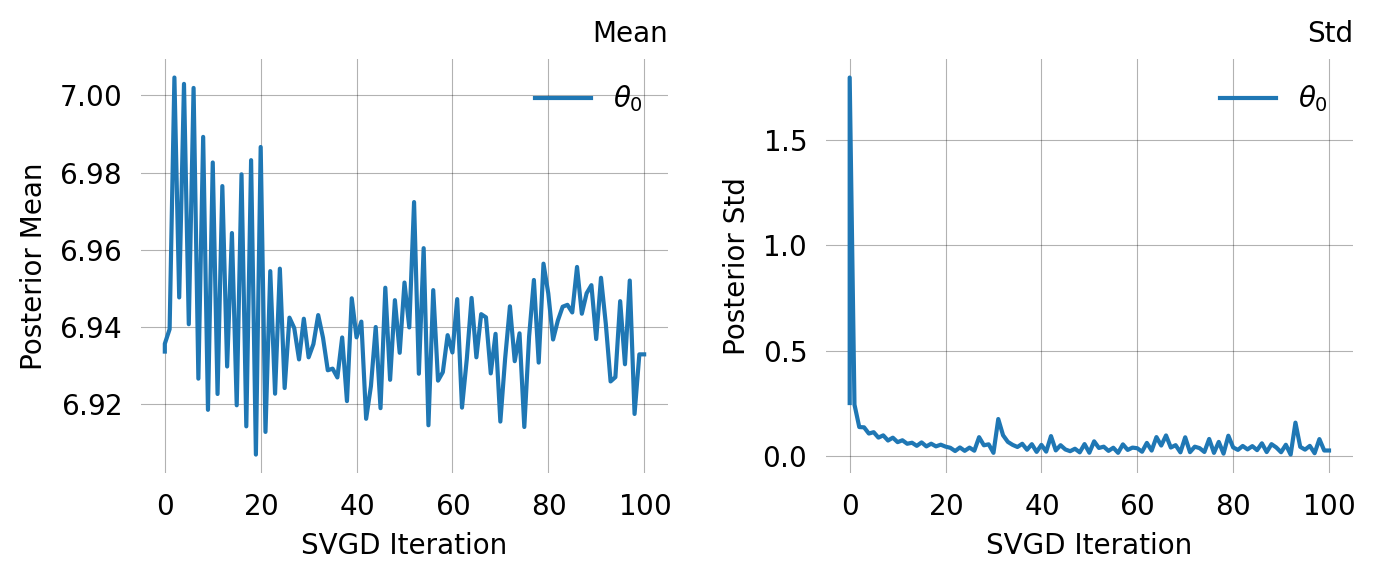

In [40]:
svgd.plot_convergence() ;

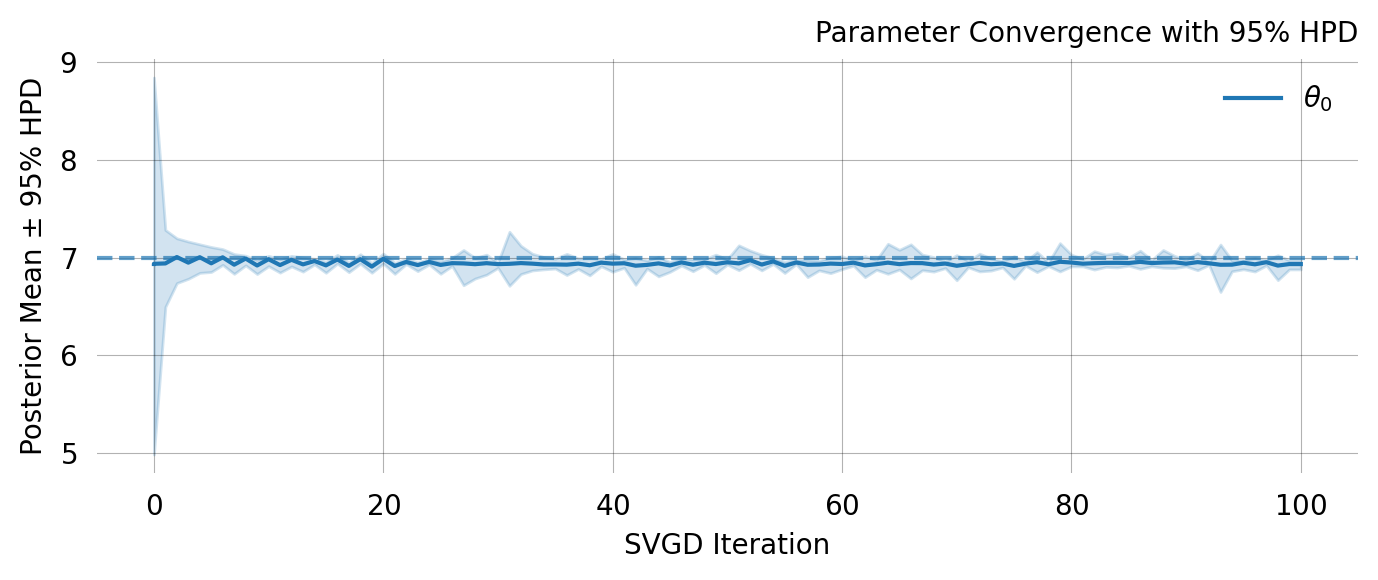

In [41]:
svgd.plot_ci(true_theta=true_theta) ;

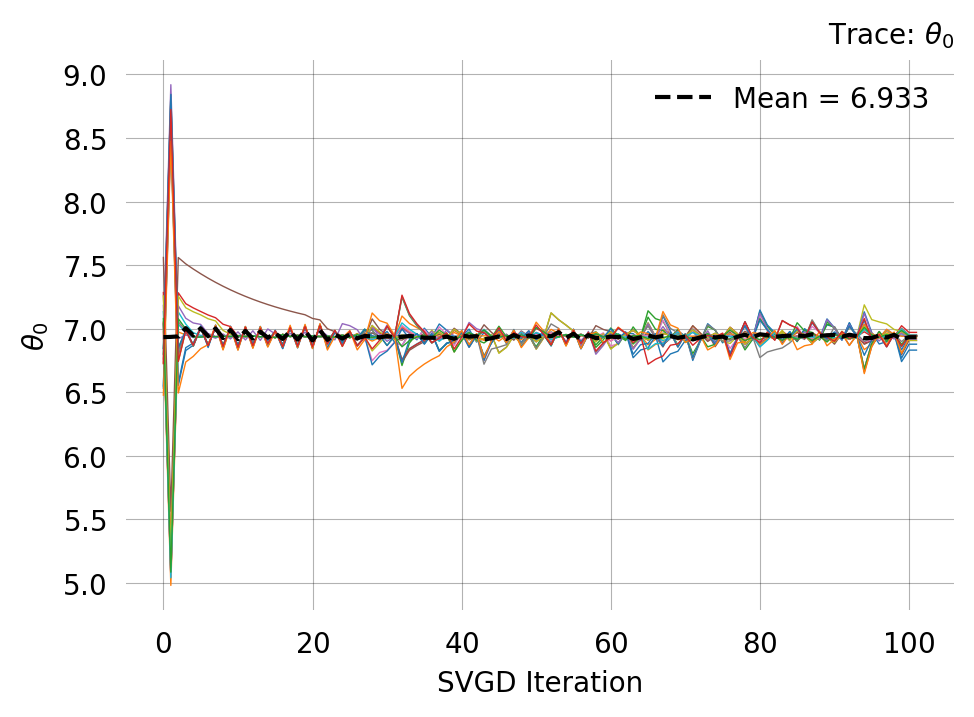

In [42]:
svgd.plot_trace() ;